# PEPS State DMRG (Single `chi`)

This notebook shows a clean end-to-end `SweepOptimizer` workflow using a **single boundary bond dimension**:

1. configure backend and contraction optimizer,
2. build and normalize initial/target PEPS states,
3. configure one sweep setup (`chi` fixed),
4. run both `debug=False` (fast) and `debug=True` (full diagnostics),
5. plot loss, boundary infidelity, timing, and norm stability.

All diagnostics are extracted from `SweepResult` and per-step `result.runs` records.


In [1]:
from pathlib import Path
import sys

import numpy as np
import matplotlib.pyplot as plt
import quimb.tensor as qtn
import torch

repo_src = Path('/Users/rezah/Documents/py/src')
if str(repo_src) not in sys.path:
    sys.path.insert(0, str(repo_src))

import pepsy as py
core = py.core

print('py version:', getattr(py, '__version__', 'unknown'))

py version: 0.1.1


In [2]:
# Core config (single chi)
Lx, Ly = 4, 4
bond_dim = 2
chi = 40

n_cycles_fast = 2
n_cycles_debug = 1

seed_state = 66
seed_target = 99

to_backend = core.backend_torch(dtype=torch.complex128)
optimizer = core.build_optimizer(progbar=True, directory='cash/', parallel=True)

print({
    'Lx': Lx,
    'Ly': Ly,
    'bond_dim': bond_dim,
    'chi': chi,
    'n_cycles_fast': n_cycles_fast,
    'n_cycles_debug': n_cycles_debug,
})

{'Lx': 4, 'Ly': 4, 'bond_dim': 2, 'chi': 40, 'n_cycles_fast': 2, 'n_cycles_debug': 1}


In [3]:
# Build initial and target PEPS, then exact-normalize both.
state_init = qtn.PEPS.rand(Lx=Lx, Ly=Ly, bond_dim=bond_dim, seed=seed_state, dtype='complex128')
target_state = qtn.PEPS.rand(Lx=Lx, Ly=Ly, bond_dim=bond_dim, seed=seed_target, dtype='complex128')


def exact_normalize_(tn, *, opt):
    old_norm = complex((tn.H & tn).contract(all, optimize=opt))
    if abs(old_norm) == 0:
        raise ZeroDivisionError('Exact norm is zero; cannot normalize state.')
    tn.multiply_(1 / (old_norm ** 0.5))
    return old_norm


old_state_norm = exact_normalize_(state_init, opt=optimizer)
old_target_norm = exact_normalize_(target_state, opt=optimizer)

# Move both networks to torch backend for gradient-based slice optimization.
state_init.apply_to_arrays(to_backend)
target_state.apply_to_arrays(to_backend)

fid0 = float(core.tn_fidelity(state_init, target_state, opt=optimizer))
print('old exact norm (state) :', old_state_norm)
print('old exact norm (target):', old_target_norm)
print('initial fidelity       :', fid0)

old exact norm (state) : (3.4154551530207014e+17-8j)
old exact norm (target): (7577076641489862-0.1875j)
initial fidelity       : 0.00010326515506634593


In [4]:
# One sweep configuration function.
def make_sweeper():
    sweeper = py.SweepOptimizer(
        state=state_init.copy(),
        state_target=target_state.copy(),
        chi=chi,
        contraction_opt=optimizer,
        renormalize_state=True,
        renormalize_kwargs={
            'n_iter': 5,
            'direction': 'y',
            'max_separation': 1,
            'progress': False,
            'track_boundary_fidelity': False,
        },
    )
    sweeper.set_optimize_kwargs(
        axes=('y', 'x'),
        n_round_trips=1,
        optimizer='scipy-lbfgs',
        optimizer_options={
            'algorithm': 'LBFGS',
            'lr': 1e-2,
            'n_steps': 40,
            'maxeval': 120,
            'ftol_rel': 1e-9,
            'xtol_rel': 1e-9,
        },
        env_n_iter=10,
        progress=True,
        renormalize=True,
    )
    return sweeper

print('optimize kwarg names:', py.SweepOptimizer.optimize_kwarg_names())
print('normalize kwarg names:', py.SweepOptimizer.normalize_kwarg_names())

optimize kwarg names: ('axes', 'chi', 'env_n_iter', 'n_cycles', 'n_round_trips', 'optimizer', 'optimizer_options', 'progress', 'renormalize', 'track_boundary_fidelity')
normalize kwarg names: ('contraction_opt', 'direction', 'max_separation', 'n_iter', 'progress', 'track_boundary_fidelity')


In [5]:
# Run sweeper — single run with boundary fidelity tracking enabled.
sweeper = make_sweeper()
result = sweeper.run(n_cycles=n_cycles_fast, chi=chi, track_boundary_fidelity=False)

# Boundary-based infidelity after run.
inf_after = sweeper.infidelity(n_iter=10, progress=False)

print('loss_before :', result['loss_before'])
print('loss_after  :', result['loss_after'])
print('infidelity  :', inf_after)
print('steps       :', len(result['runs']))
print('fidels tracked:', len(sweeper.fidels))

bdy_dmrg:: 100%|██████████████████████████████| 40/40 [00:14<00:00,  2.69it/s, loss=0.059509, t_bdy=0.15s, t_opt=0.07s, slice=x_fwd_3]


loss_before : 0.9998967348449337
loss_after  : 0.05950882834812654
infidelity  : 0.05950882834812943
steps       : 40
fidels tracked: 40


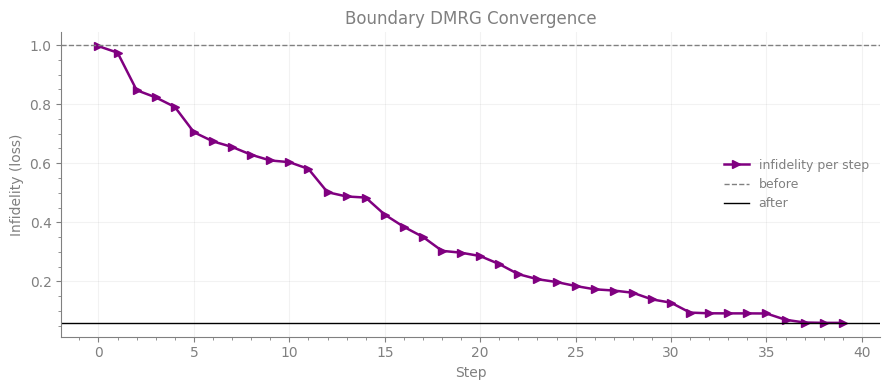

final loss: 0.0595088283481261


In [6]:
import quimb as qu

# Plot 1: per-step infidelity (loss) convergence.
with plt.style.context(qu.NEUTRAL_STYLE):
    fig, ax = plt.subplots(figsize=(9, 4))
    ax.plot(sweeper.loss, color='purple', marker='>', lw=1.8, label='infidelity per step')
    ax.axhline(result['loss_before'], color='gray', ls='--', lw=1.0, label='before')
    ax.axhline(result['loss_after'],  color='black', ls='-',  lw=1.0, label='after')
    ax.set_title('Boundary DMRG Convergence')
    ax.set_ylabel('Infidelity (loss)')
    ax.set_xlabel('Step')
    ax.legend(frameon=False, fontsize=9)
    fig.tight_layout()
    plt.show()

print('final loss:', sweeper.loss[-1] if sweeper.loss else None)

/var/folders/jb/v1_qckn92vdbjrcrvtc0d0340000gn/T/ipykernel_26541/2822944044.py:17: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(frameon=False, fontsize=9)


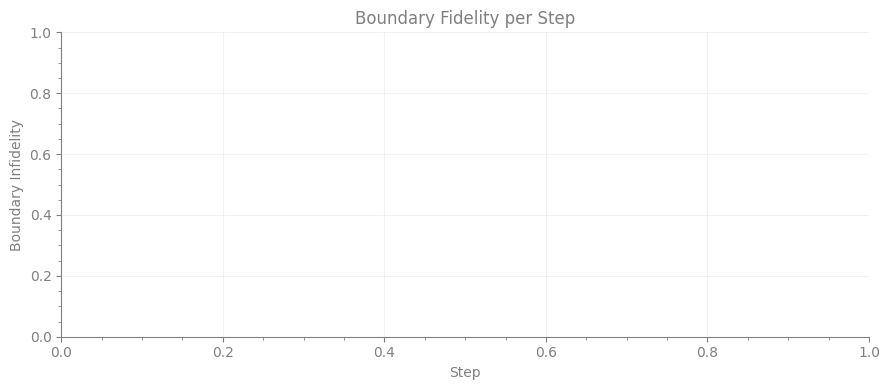

In [7]:
# Plot 2: boundary fidelity per step (norm and overlap).
norm_fidels    = [f['norm']    for f in sweeper.fidels]
overlap_fidels = [f['overlap'] for f in sweeper.fidels]

with plt.style.context(qu.NEUTRAL_STYLE):
    fig, ax = plt.subplots(figsize=(9, 4))
    steps = range(1, len(sweeper.fidels) + 1)
    if any(v is not None for v in norm_fidels):
        ys = [v if v is not None else float('nan') for v in norm_fidels]
        ax.plot(steps, ys, color='orange', lw=1.6, label='boundary infidelity norm')
    if any(v is not None for v in overlap_fidels):
        ys = [v if v is not None else float('nan') for v in overlap_fidels]
        ax.plot(steps, ys, color='teal', lw=1.6, label='boundary infidelity overlap')
    ax.set_title('Boundary Fidelity per Step')
    ax.set_ylabel('Boundary Infidelity')
    ax.set_xlabel('Step')
    ax.legend(frameon=False, fontsize=9)
    fig.tight_layout()
    plt.show()

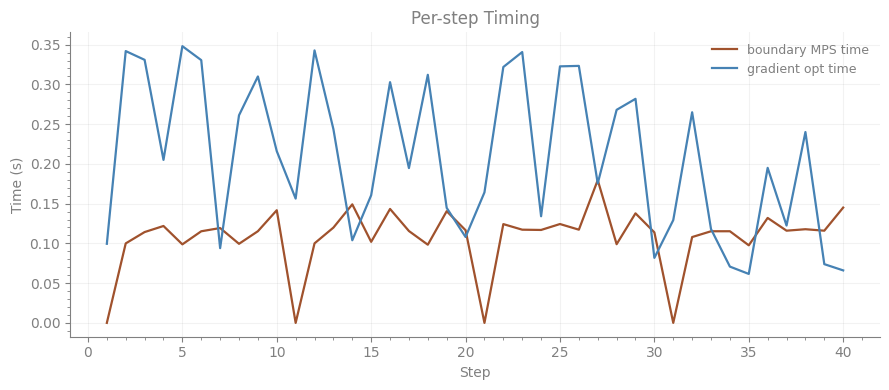

mean t_bdy: 0.108s  |  mean t_opt: 0.209s


In [8]:
# Plot 3: per-step timing (boundary MPS update vs gradient optimization).
runs = result['runs']
t_bdy = [r.get('time_boundary') for r in runs]
t_opt = [r.get('time_optimize') for r in runs]
steps = range(1, len(runs) + 1)

with plt.style.context(qu.NEUTRAL_STYLE):
    fig, ax = plt.subplots(figsize=(9, 4))
    ax.plot(steps, t_bdy, color='sienna', lw=1.6, label='boundary MPS time')
    ax.plot(steps, t_opt, color='steelblue', lw=1.6, label='gradient opt time')
    ax.set_title('Per-step Timing')
    ax.set_ylabel('Time (s)')
    ax.set_xlabel('Step')
    ax.legend(frameon=False, fontsize=9)
    fig.tight_layout()
    plt.show()

t_bdy_arr = [v for v in t_bdy if v is not None]
t_opt_arr = [v for v in t_opt if v is not None]
if t_bdy_arr:
    print(f'mean t_bdy: {sum(t_bdy_arr)/len(t_bdy_arr):.3f}s  |  mean t_opt: {sum(t_opt_arr)/len(t_opt_arr):.3f}s')

In [9]:
# Numeric summary.
print(f"loss_before : {result['loss_before']:.6f}")
print(f"loss_after  : {result['loss_after']:.6f}")
print(f"infidelity  : {inf_after:.6f}")
print(f"norm_trace  : {[f'{v:.4f}' for v in result['norm_trace']]}")
print(f"steps       : {len(result['runs'])}")

loss_before : 0.999897
loss_after  : 0.059509
infidelity  : 0.059509
norm_trace  : ['1.0000', '74418898373301.0000', '102.3078', '3.5275', '1.4585']
steps       : 40


## Minimal production call

Use this when you want speed and fewer diagnostics:

```python
sweeper = make_sweeper()
result = sweeper.run(n_cycles=3, debug=False, chi=chi)
print(result.loss_before, '->', result.loss_after)
```

Use `debug=True` when you need full per-step diagnostics (`exact_loss_after`, boundary infidelity, and state norm trace).
